After running *pyomo_tclab_v10.py*, run this notebook to:
- load ipopt solution
- run ODE solver on each draw
- produce plots

In [1]:
from FoKL import FoKLRoutines
import os
dir = os.path.abspath('')  # directory of notebook
# -----------------------------------------------------------------------
# UNCOMMENT IF USING LOCAL FOKL PACKAGE:
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
GP = FoKLRoutines.load(os.path.join(dir, "models", "pyomo_tclab_v10.fokl"))

In [7]:
u_df = pd.read_csv(os.path.join(dir, "data", "pyomo_tclab_v10_ipopt_u.csv"))

tvec = u_df["Time"].values
dt = tvec[1] - tvec[0]  # const.

draws_vec = u_df.columns.values.tolist()
draws_vec.remove("Unnamed: 0")
draws_vec.remove("Time")

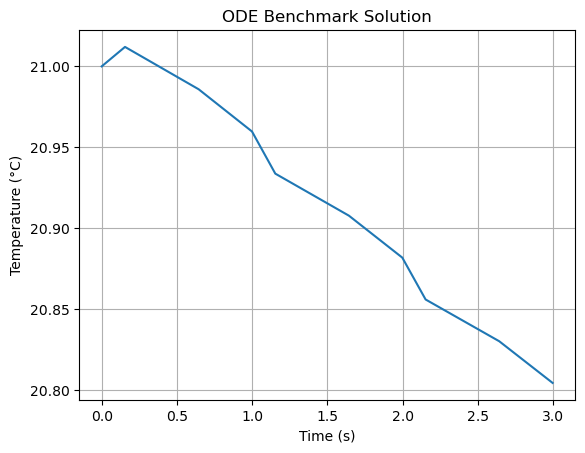

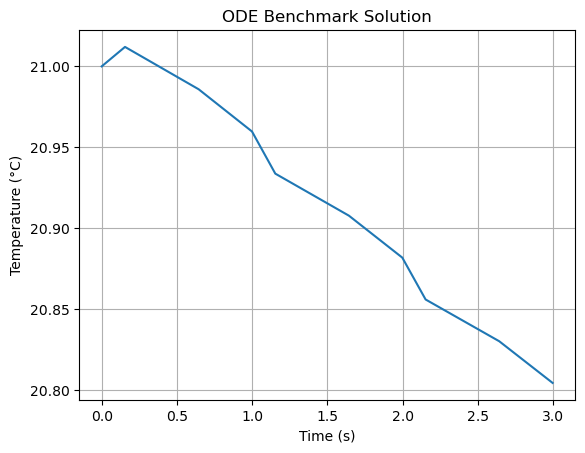

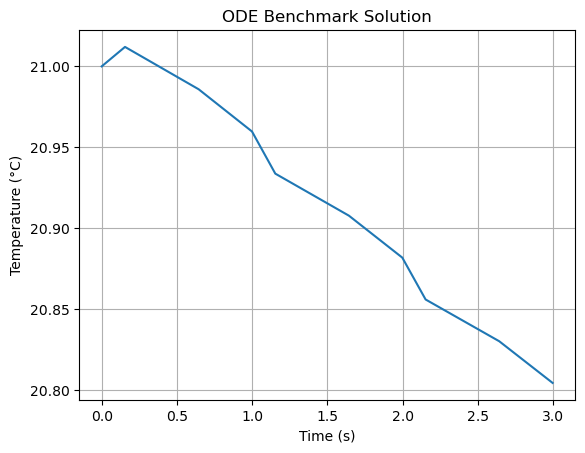

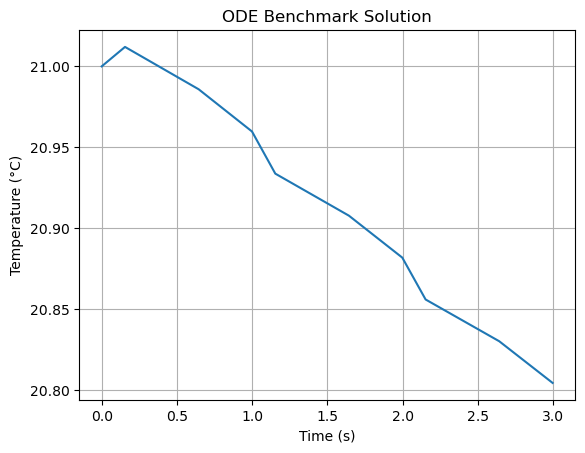

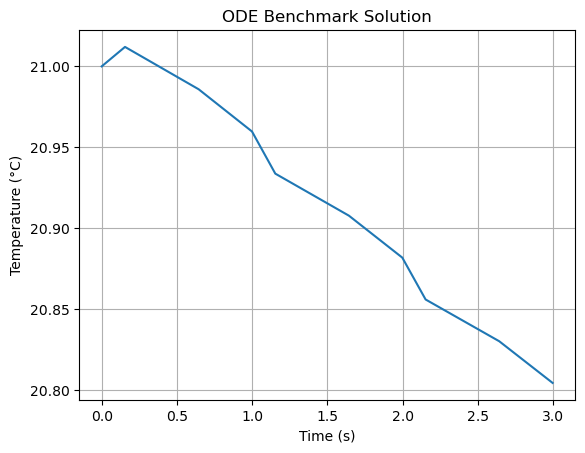

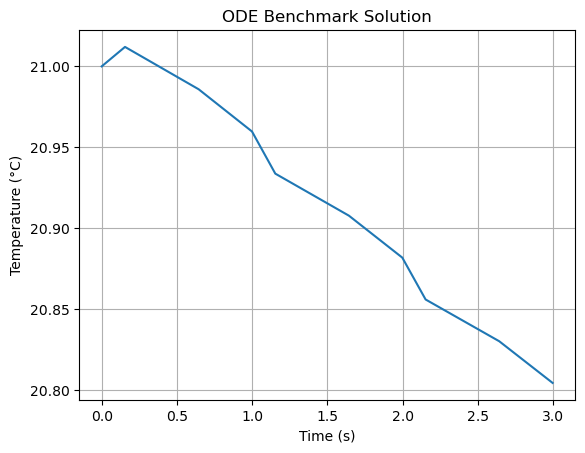

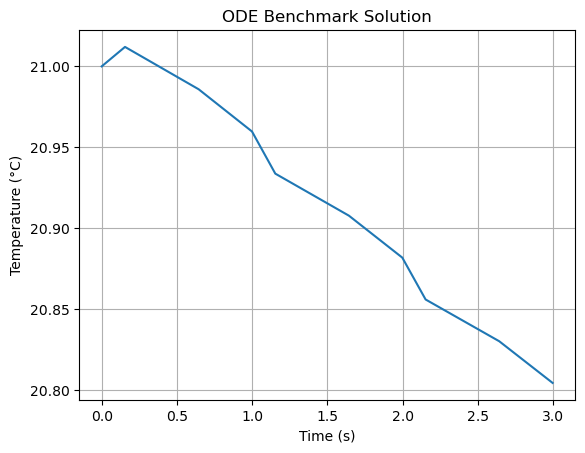

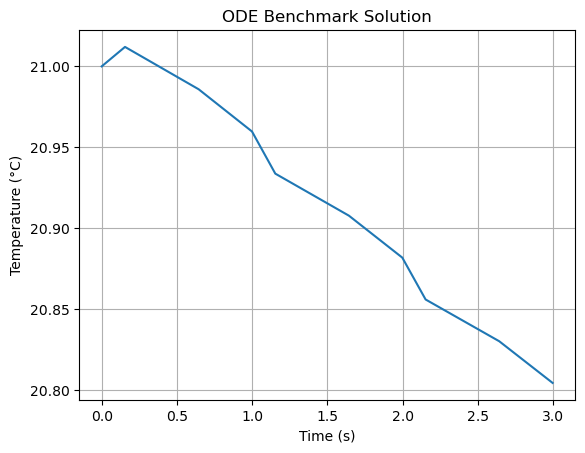

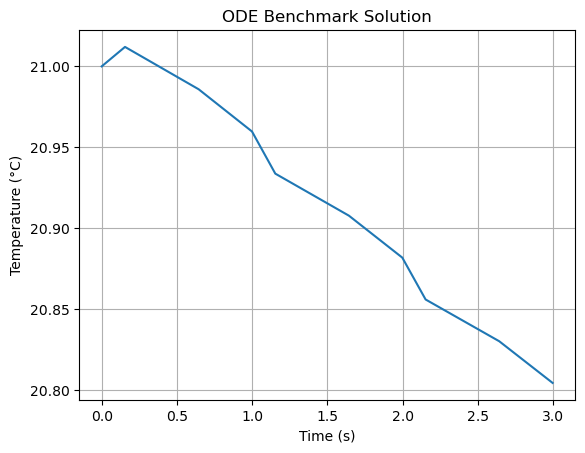

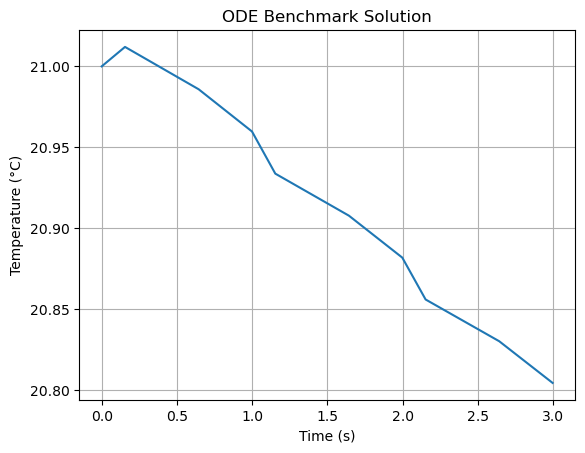

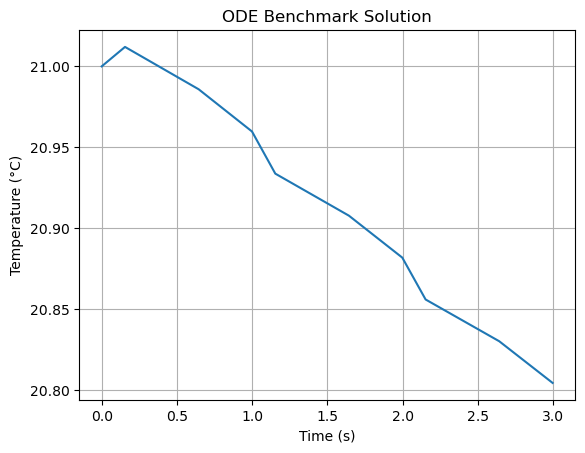

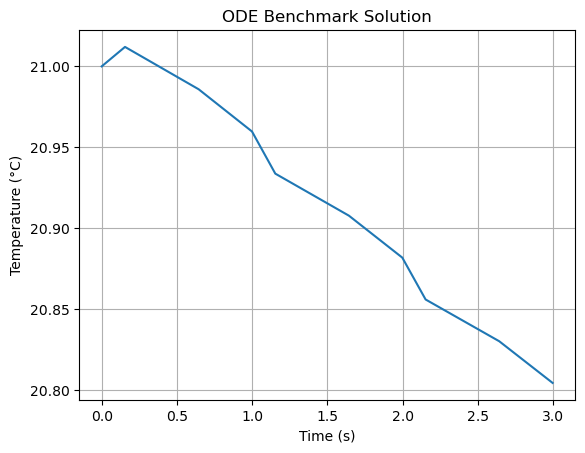

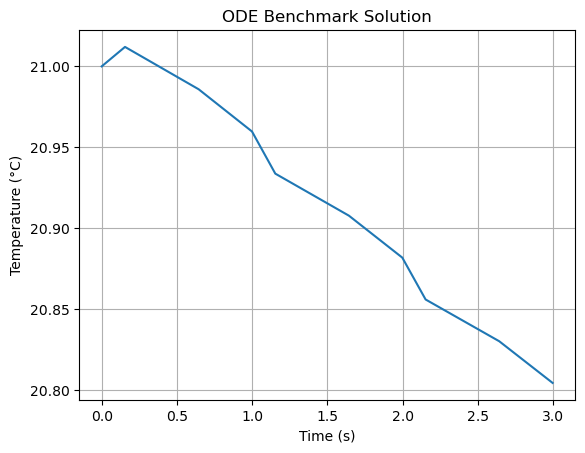

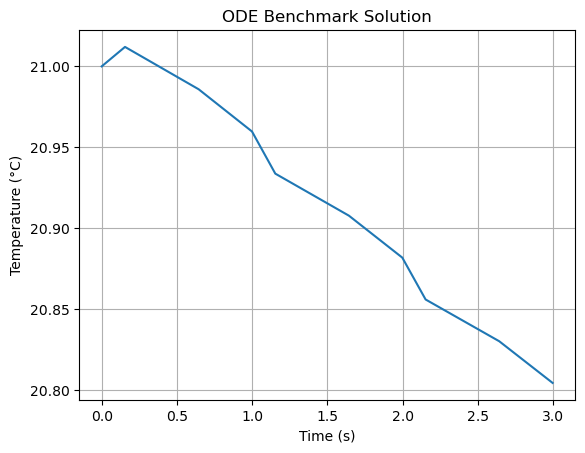

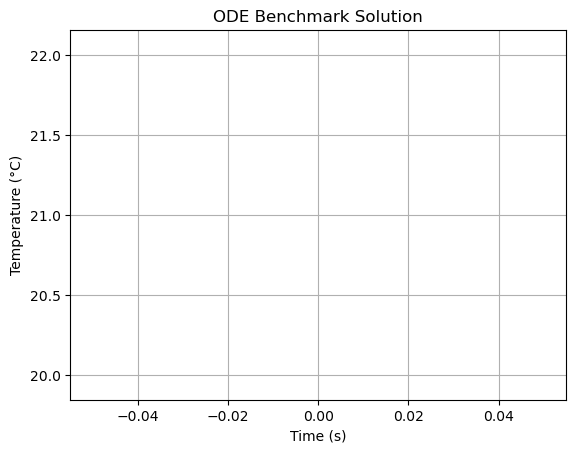

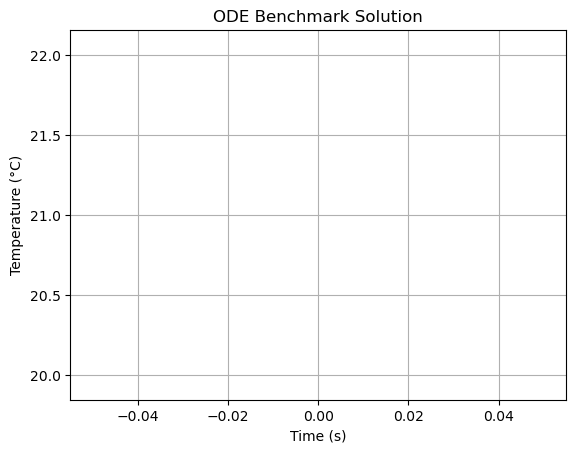

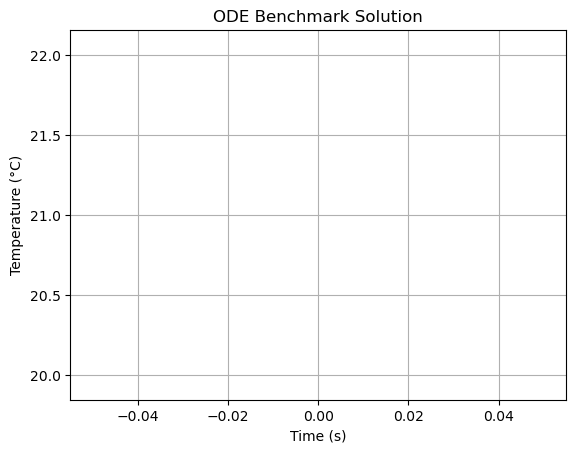

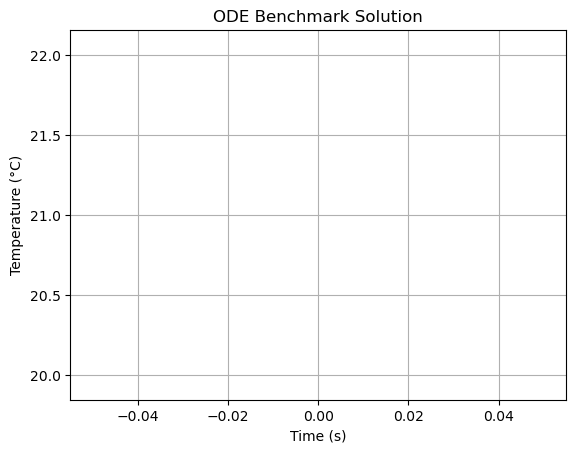

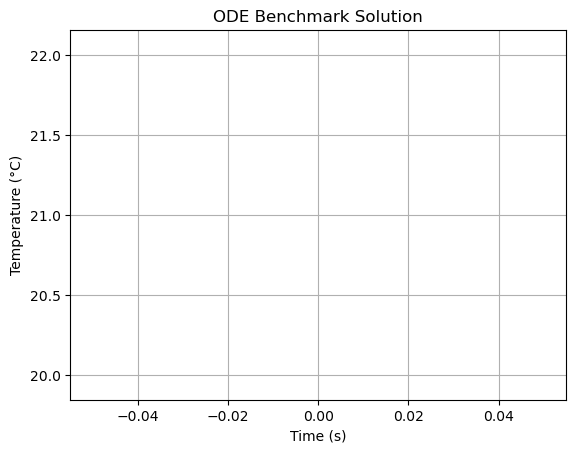

In [19]:
Tamb = 21
uvec = []
solns = []
plt.figure()
for draws in draws_vec:
    u = interp1d(tvec, u_df[draws].values, kind='previous')  # assume real-world implementation uses 'previous'
    
    # def dTdt(t, T):
    #     """ODE to integrate GP of derivative."""
    #     return [GP.evaluate([T[0], u(t)], clean=True, SingleInstance=True)[0]]  # == dT/dt

    # soln = solve_ivp(dTdt, [tvec[0], tvec[-1]], [Tamb], 'LSODA', tvec, first_step=dt, min_step=dt, max_step=dt)

    #=========================================
    #Manual integral
    yy = 10
    T = np.zeros_like(tvec[:yy])
    T[0] = Tamb
    i = -1
    # for t in tvec[:-1]:
    for t in tvec[:(yy-1)]:
        i += 1
        dT = GP.evaluate([T[i], u(t)], clean=True, SingleInstance=True)[0]
        T[i + 1] = T[i] + dT * dt
    #=========================================

    # plt.figure()
    # plt.plot(tr, r(tr))
    # plt.plot(tvec, soln.y[0])
    plt.plot(tvec[:yy], T)
    plt.grid()
    plt.title('ODE Benchmark Solution')
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (°C)')
    # _ = plt.legend(['Measured', 'Benchmark'])

    uvec.append(u)
    # solns.append(soln)

In [ ]:
# WITH MINIMUM 'draws' S.T. SOLUTION IS STEADY, CALCULATE ODE PER DRAW.

draws = 50  # for example, i.e., const.

Tamb_vec = [Tamb] * draws

def dTdt(t, T):
    """ODE to integrate GP of derivative, per draw."""
    dT = []
    for i in range(draws):
        betas = GP.betas[-(i + 1), :]  # betas for single draw
        dT.append(GP.evaluate([T[i], u(t)], betas, clean=True, SingleInstance=True)[0])
    return dT
    
soln = solve_ivp(dTdt, [tvec[0], tvec[-1]], Tamb_vec, 'LSODA', tvec, first_step=dt, min_step=dt, max_step=dt)